# Stage 6 — Food Pairing Hypothesis

**Hypothesis (Ahn et al., Scientific Reports, 2011):**
> Ingredients sharing more flavor compounds tend to co-occur more often in recipes.

**From the literature:**
- Western cuisine → hypothesis is **supported** (ρ > 0)
- East Asian cuisine → hypothesis is **rejected** (ρ < 0)

**Our analysis:** Spearman ρ, point-biserial, permutation test — globally and per cuisine.

**Input files:** `output_graphs/ingredient_graph.graphml`, `output_graphs/node_features.npz`,
`output_graphs/recipe_embeddings.npz`, `full_dataset.csv`

In [1]:
import ast, json, warnings, time
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

OUT  = Path('output_graphs')
SEED = 42
rng  = np.random.default_rng(SEED)
print('Imports OK')

Imports OK


## 6.1 Loading data

In [2]:
print('Loading graph I...')
I = nx.read_graphml(OUT / 'ingredient_graph.graphml')
print(f'  Nodes: {I.number_of_nodes():,}  Edges: {I.number_of_edges():,}')

npz        = np.load(OUT / 'node_features.npz', allow_pickle=True)
feat_nodes = list(npz['nodes'])
X_chem     = npz['chem_matrix'].astype(np.float32)
has_chem   = npz['has_chem']

chem_nodes = [name for name, has in zip(feat_nodes, has_chem)
              if has and name in I]
feat_idx   = {name: i for i, name in enumerate(feat_nodes)}
X_chem_sub = np.stack([X_chem[feat_idx[n]] for n in chem_nodes])
X_chem_sub = normalize(X_chem_sub, norm='l2')
print(f'  Ingredients with chemical data in graph: {len(chem_nodes):,}')

emb_data          = np.load(OUT / 'recipe_embeddings.npz', allow_pickle=True)
recipe_ids_arr    = list(emb_data['recipe_ids'])
cuisine_arr       = list(emb_data['cuisine_labels'])
recipe_to_cuisine = dict(zip(recipe_ids_arr, cuisine_arr))
print('Cuisine distribution:')
print(pd.Series(cuisine_arr).value_counts().to_string())

Loading graph I...
  Nodes: 7,199  Edges: 418,645
  Ingredients with chemical data in graph: 4,942
Cuisine distribution:
american    200000


In [3]:
print('Loading recipes...')
DATA_PATH = Path('full_dataset.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('data_sample.csv')
    print(f'[!] full_dataset.csv not found, using {DATA_PATH} (smoke test, 5k rows)')
df_ner = pd.read_csv(DATA_PATH, nrows=200_000, usecols=['NER'])
df_ner['ner_list'] = df_ner['NER'].apply(ast.literal_eval)
recipe_ner = {
    f'recipe::{i}': [x.lower().strip() for x in row['ner_list']]
    for i, row in df_ner.iterrows()
}
chem_set = set(chem_nodes)
print(f'Loaded {len(recipe_ner):,} recipes')

Loading recipes...
Loaded 200,000 recipes


## 6.2 Chemical similarity matrix

We compute pairwise cosine similarity of Morgan fingerprints for all M ingredients with chemical data.
At M ≈ 1200 the (M×M) matrix occupies ~5.5 MB and fits in RAM.

In [4]:
print('Computing chemical similarity matrix...', end=' ', flush=True)
t0 = time.time()
SIM_CHEM = cosine_similarity(X_chem_sub)  # already L2-normalised → dot product
print(f'{time.time()-t0:.1f}s')
print(f'Matrix: {SIM_CHEM.shape}')
print(f'Values: min={SIM_CHEM.min():.3f}, mean={SIM_CHEM.mean():.3f}, max={SIM_CHEM.max():.3f}')
chem_idx = {name: i for i, name in enumerate(chem_nodes)}

Computing chemical similarity matrix... 0.1s
Matrix: (4942, 4942)
Values: min=0.000, mean=0.786, max=1.000


## 6.3 Global hypothesis test

For each pair `(a, b)` with chemical data:
- `chem_sim` = cosine(fingerprint_a, fingerprint_b)
- `in_graph` = 1 if they are connected in I, 0 otherwise
- `cooc_weight` = edge weight (number of shared recipes)

Tests: Spearman ρ, point-biserial r, Mann-Whitney U

In [5]:
MAX_PAIRS = 200_000

M = len(chem_nodes)
total_pairs = M * (M - 1) // 2
print(f'Total unique pairs: {total_pairs:,}')

if total_pairs <= MAX_PAIRS:
    pair_indices = [(i, j) for i in range(M) for j in range(i+1, M)]
else:
    pair_set = set()
    while len(pair_set) < MAX_PAIRS:
        i, j = rng.integers(0, M, 2)
        if i != j:
            pair_set.add((min(i,j), max(i,j)))
    pair_indices = list(pair_set)

print(f'Pairs to analyse: {len(pair_indices):,}')

records = []
for i, j in tqdm(pair_indices, desc='Collecting pairs', miniters=10000):
    a, b     = chem_nodes[i], chem_nodes[j]
    chem_sim = float(SIM_CHEM[i, j])
    if I.has_edge(a, b):
        in_graph = 1
        cooc_w   = int(I[a][b].get('weight', 1))
    else:
        in_graph = 0
        cooc_w   = 0
    records.append((a, b, chem_sim, in_graph, cooc_w))

df_pairs = pd.DataFrame(records, columns=['a','b','chem_sim','in_graph','cooc_weight'])
print(f'Share of connected pairs: {df_pairs["in_graph"].mean():.3f}')
df_pairs.describe().round(3)

Total unique pairs: 12,209,211
Pairs to analyse: 200,000


Share of connected pairs: 0.022


,chem_sim,in_graph,cooc_weight
count,200000.000,200000.000,200000.000
mean,0.786,0.022,4.623
std,0.168,0.148,283.187
min,0.053,0.000,0.000
25%,0.639,0.000,0.000
50%,0.824,0.000,0.000
75%,0.941,0.000,0.000
max,1.000,1.000,73267.000


In [6]:
rho_all, p_all = stats.spearmanr(df_pairs['chem_sim'], df_pairs['cooc_weight'])

rpb, p_pb = stats.pointbiserialr(df_pairs['in_graph'], df_pairs['chem_sim'])

sim_pos = df_pairs.loc[df_pairs['in_graph']==1, 'chem_sim']
sim_neg = df_pairs.loc[df_pairs['in_graph']==0, 'chem_sim']
u_stat, p_mw = stats.mannwhitneyu(sim_pos, sim_neg, alternative='greater')
effect_r = 1 - 2*u_stat / (len(sim_pos)*len(sim_neg))
diff = sim_pos.mean() - sim_neg.mean()

print('=== Global Food Pairing Hypothesis test ===')
print(f'Spearman ρ (chem_sim vs cooc_weight): {rho_all:+.4f}  p={p_all:.2e}')
print(f'Point-biserial r (chem_sim vs edge):  {rpb:+.4f}  p={p_pb:.2e}')
print(f'Mann-Whitney (pos > neg):              p={p_mw:.2e}  effect r={effect_r:+.4f}')
print(f'Mean chem_sim CONNECTED   : {sim_pos.mean():.4f}')
print(f'Mean chem_sim NOT-CONNECTED: {sim_neg.mean():.4f}')
print(f'Δ = {diff:+.5f}')
if rho_all > 0 and p_all < 0.05:
    print('\n[+] Hypothesis SUPPORTED: ingredients with similar molecules are paired more often')
elif rho_all < 0 and p_all < 0.05:
    print('\n[-] Hypothesis REJECTED: cuisine avoids molecularly similar ingredients')
else:
    print('\n[~] Statistically not significant (p >= 0.05)')

=== Global Food Pairing Hypothesis test ===
Spearman ρ (chem_sim vs cooc_weight): +0.0150  p=1.97e-11
Point-biserial r (chem_sim vs edge):  +0.0154  p=6.45e-12
Mann-Whitney (pos > neg):              p=8.18e-12  effect r=-0.0587
Mean chem_sim CONNECTED   : 0.8026
Mean chem_sim NOT-CONNECTED: 0.7852
Δ = +0.01739

[+] Hypothesis SUPPORTED: ingredients with similar molecules are paired more often


## 6.4 Per-cuisine test

We build an internal co-occurrence graph per cuisine and compute ρ separately.

In [7]:
def cuisine_pair_stats(recipe_list, recipe_ner, chem_set, chem_idx, SIM_CHEM,
                       chem_nodes, max_pairs=50_000):
    from collections import Counter
    cooc = Counter()
    all_ings = set()
    for rid in recipe_list:
        ings = [x for x in recipe_ner.get(rid, []) if x in chem_set]
        all_ings.update(ings)
        for a, b in combinations(sorted(set(ings)), 2):
            cooc[frozenset({a,b})] += 1
    if len(cooc) < 100:
        return None
    pairs = list(combinations(sorted(all_ings), 2))
    if len(pairs) > max_pairs:
        idx = rng.choice(len(pairs), max_pairs, replace=False)
        pairs = [pairs[k] for k in idx]
    cs, cw, ig = [], [], []
    for a, b in pairs:
        ia, ib = chem_idx.get(a), chem_idx.get(b)
        if ia is None or ib is None:
            continue
        cs.append(float(SIM_CHEM[ia, ib]))
        w = cooc.get(frozenset({a,b}), 0)
        cw.append(w)
        ig.append(1 if w > 0 else 0)
    if len(cs) < 100:
        return None
    cs, cw, ig = np.array(cs), np.array(cw), np.array(ig)
    rho, p = stats.spearmanr(cs, cw)
    pos, neg = cs[ig==1], cs[ig==0]
    return dict(n_pairs=len(cs), spearman_rho=round(rho,4), p_value=round(p,4),
                delta=round(float(pos.mean()-neg.mean()),5) if len(pos)>0 and len(neg)>0 else None,
                chem_sims=cs, in_graph=ig)

cuisine_to_recipes = {}
for rid, c in recipe_to_cuisine.items():
    if c != 'unknown':
        cuisine_to_recipes.setdefault(c, []).append(rid)

results_by_cuisine = {}
for cuisine, recipe_list in sorted(cuisine_to_recipes.items(), key=lambda x: -len(x[1])):
    print(f'{cuisine:<22} ({len(recipe_list):>5,} recipes)...', end=' ')
    res = cuisine_pair_stats(recipe_list, recipe_ner, chem_set, chem_idx, SIM_CHEM, chem_nodes)
    if res:
        results_by_cuisine[cuisine] = res
        sig = '***' if res['p_value']<0.001 else ('**' if res['p_value']<0.01 else ('*' if res['p_value']<0.05 else 'n.s.'))
        print(f'ρ={res["spearman_rho"]:+.4f} {sig}  Δ={res["delta"]}')
    else:
        print('skipped (too few pairs)')

american               (200,000 recipes)... ρ=+0.0126 **  Δ=0.01249


In [8]:
rows = []
for cuisine, res in results_by_cuisine.items():
    rows.append({'cuisine': cuisine,
                 'spearman_rho': res['spearman_rho'],
                 'p_value': res['p_value'],
                 'n_pairs': res['n_pairs'],
                 'delta': res.get('delta'),
                 'significant': res['p_value'] < 0.05,
                 'FPH': '↑ supports' if res['spearman_rho'] > 0 else '↓ contradicts'})
rows.append({'cuisine': '[GLOBAL]', 'spearman_rho': rho_all, 'p_value': p_all,
             'n_pairs': len(df_pairs), 'delta': diff,
             'significant': p_all < 0.05, 'FPH': '↑ supports' if rho_all > 0 else '↓ contradicts'})
df_res = pd.DataFrame(rows).sort_values('spearman_rho', ascending=False)
print(df_res.to_string(index=False))

 cuisine  spearman_rho      p_value  n_pairs    delta  significant        FPH
[GLOBAL]      0.014999 1.973246e-11   200000 0.017389         True ↑ supports
american      0.012600 5.000000e-03    50000 0.012490         True ↑ supports


## 6.5 Permutation test

Is the observed Δ random? We shuffle `in_graph` labels 1000 times.

In [9]:
def permutation_test(chem_sims, in_graph, n=1000, seed=42):
    rng_pt   = np.random.default_rng(seed)
    obs_diff = chem_sims[in_graph==1].mean() - chem_sims[in_graph==0].mean()
    null = np.array([
        chem_sims[rng_pt.permutation(in_graph)==1].mean() -
        chem_sims[rng_pt.permutation(in_graph)==0].mean()
        for _ in range(n)
    ])
    p_perm = (np.abs(null) >= np.abs(obs_diff)).mean()
    return {'observed': obs_diff, 'null_mean': null.mean(), 'null_std': null.std(),
            'p_perm': p_perm, 'null': null}

print('Permutation test (1000 iterations)...', end=' ', flush=True)
t0 = time.time()
perm = permutation_test(df_pairs['chem_sim'].values, df_pairs['in_graph'].values)
print(f'{time.time()-t0:.1f}s')
print(f'Observed Δ        : {perm["observed"]:+.6f}')
print(f'Null (mean ± std) : {perm["null_mean"]:+.6f} ± {perm["null_std"]:.6f}')
print(f'p (permutation)   : {perm["p_perm"]:.4f}')

Permutation test (1000 iterations)... 6.5s
Observed Δ        : +0.017389
Null (mean ± std) : -0.000075 ± 0.002434
p (permutation)   : 0.0000


## 6.6 Visualization

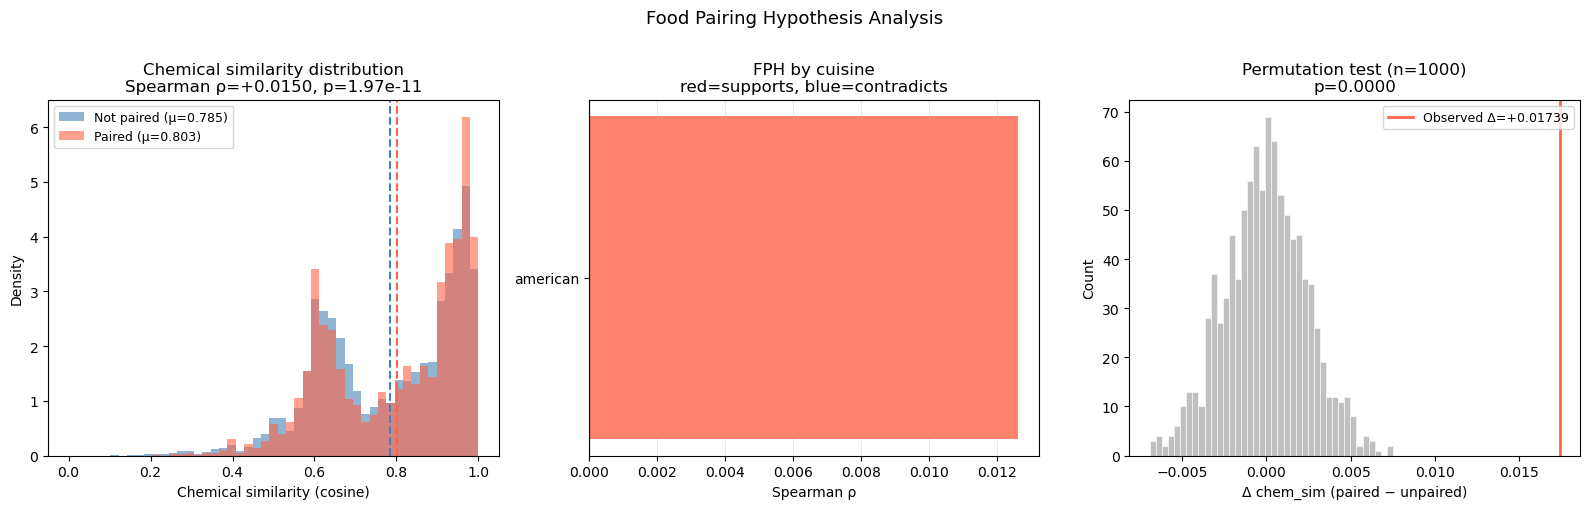

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bins = np.linspace(0, 1, 50)
axes[0].hist(sim_neg, bins=bins, alpha=0.6, color='steelblue',
             label=f'Not paired (μ={sim_neg.mean():.3f})', density=True)
axes[0].hist(sim_pos, bins=bins, alpha=0.6, color='tomato',
             label=f'Paired (μ={sim_pos.mean():.3f})', density=True)
axes[0].axvline(sim_neg.mean(), color='steelblue', linestyle='--', lw=1.5)
axes[0].axvline(sim_pos.mean(), color='tomato', linestyle='--', lw=1.5)
axes[0].set_xlabel('Chemical similarity (cosine)')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Chemical similarity distribution\nSpearman ρ={rho_all:+.4f}, p={p_all:.2e}')
axes[0].legend(fontsize=9)

df_plot = df_res[df_res['cuisine'] != '[GLOBAL]'].sort_values('spearman_rho', ascending=True)
colors_bar = ['steelblue' if r < 0 else 'tomato' for r in df_plot['spearman_rho']]
axes[1].barh(df_plot['cuisine'], df_plot['spearman_rho'], color=colors_bar, alpha=0.8)
axes[1].axvline(0, color='black', lw=0.8)
for _, row in df_plot.iterrows():
    if not row['significant']:
        x = row['spearman_rho']
        axes[1].text(x + (0.001 if x >= 0 else -0.001),
                     list(df_plot['cuisine']).index(row['cuisine']),
                     'n.s.', va='center', fontsize=8, color='grey',
                     ha='left' if x >= 0 else 'right')
axes[1].set_xlabel('Spearman ρ')
axes[1].set_title('FPH by cuisine\nred=supports, blue=contradicts')
axes[1].grid(axis='x', alpha=0.3)

axes[2].hist(perm['null'], bins=40, color='silver', edgecolor='white', linewidth=0.4)
axes[2].axvline(perm['observed'], color='tomato', lw=2,
                label=f'Observed Δ={perm["observed"]:+.5f}')
axes[2].set_xlabel('Δ chem_sim (paired − unpaired)')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Permutation test (n=1000)\np={perm["p_perm"]:.4f}')
axes[2].legend(fontsize=9)

plt.suptitle('Food Pairing Hypothesis Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT / 'food_pairing_global.png', dpi=150, bbox_inches='tight')
plt.show()

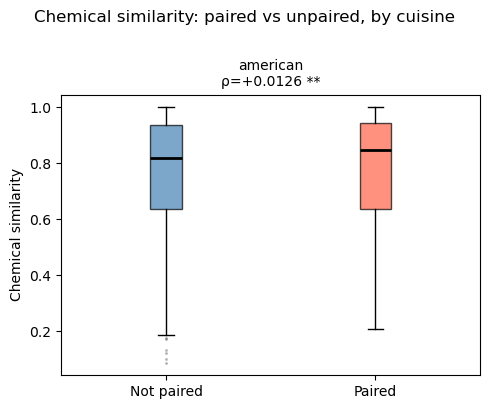

In [11]:
cuisines_with_data = [(c, r) for c, r in results_by_cuisine.items() if 'chem_sims' in r]
if cuisines_with_data:
    n = len(cuisines_with_data)
    nc = min(3, n); nr = (n + nc - 1) // nc
    fig, axes = plt.subplots(nr, nc, figsize=(5*nc, 4*nr))
    ax_list = np.array(axes).flatten() if n > 1 else [axes]
    for ax, (cname, res) in zip(ax_list, cuisines_with_data):
        sims = res['chem_sims']; ig = res['in_graph']
        bp = ax.boxplot([sims[ig==0], sims[ig==1]], labels=['Not paired','Paired'],
                        patch_artist=True,
                        medianprops=dict(color='black', lw=2),
                        flierprops=dict(marker='.', markersize=2, alpha=0.3))
        bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_facecolor('tomato');    bp['boxes'][1].set_alpha(0.7)
        sig = '***' if res['p_value']<0.001 else ('**' if res['p_value']<0.01 else ('*' if res['p_value']<0.05 else 'n.s.'))
        ax.set_title(f'{cname}\nρ={res["spearman_rho"]:+.4f} {sig}', fontsize=10)
        ax.set_ylabel('Chemical similarity')
    for ax in ax_list[n:]:
        ax.set_visible(False)
    plt.suptitle('Chemical similarity: paired vs unpaired, by cuisine', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(OUT / 'food_pairing_boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6.7 Top-15 pairs: highest / lowest chemical similarity

In [12]:
df_pos_pairs = df_pairs[df_pairs['in_graph']==1]
print('Top-15 connected pairs by HIGH chemical similarity:')
print(df_pos_pairs.nlargest(15,'chem_sim')[['a','b','chem_sim','cooc_weight']].to_string(index=False))
print('\nTop-15 connected pairs by LOW chemical similarity:')
print(df_pos_pairs.nsmallest(15,'chem_sim')[['a','b','chem_sim','cooc_weight']].to_string(index=False))

Top-15 connected pairs by HIGH chemical similarity:
                          a                      b  chem_sim  cooc_weight
     fresh coriander leaves       ground coriander  1.000004           51
              cherry jell-o     cherry pie filling  1.000003           15
           vanilla frosting         vanilla wafers  1.000003           16
                    vanilla       vanilla caramels  1.000003           39
                coconut oil    unsweetened coconut  1.000003           90
              fresh spinach                spinach  1.000002           18
        ground black pepper  scotch bonnet peppers  1.000002           11
freshly ground black pepper            red peppers  1.000002          184
             cayenne pepper          ground pepper  1.000002          283
             cayenne pepper         cracked pepper  1.000002           18
                     pepper sweet red bell peppers  1.000002           14
freshly ground black pepper           pepperoncini  1.000002

## 6.8 Summary and saving

In [13]:
print('=== Food Pairing Hypothesis summary ===')
print(f'Ingredients with chemical data: {len(chem_nodes):,}')
print(f'Global Spearman ρ = {rho_all:+.4f}  (p={p_all:.2e})')
print(f'Δ (paired − unpaired) = {diff:+.5f}')
print(f'Permutation p = {perm["p_perm"]:.4f}')
print()
print(df_res[['cuisine','spearman_rho','p_value','significant','FPH']].to_string(index=False))
print()
print('Limitations:')
print('1. RecipeNLG is predominantly English-language -> cuisine sample is imbalanced')
print('2. FlavorDB covers ~17% of the ingredients')
print('3. URL-based cuisine proxy labels are a coarse approximation')
print('4. Tanimoto similarity is preferable to cosine for bit-vector fingerprints')

save_cols = ['cuisine','spearman_rho','p_value','n_pairs','delta','significant','FPH']
df_res[[c for c in save_cols if c in df_res.columns]].to_csv(
    OUT / 'food_pairing_results.csv', index=False)
with open(OUT / 'food_pairing_summary.json', 'w') as f:
    json.dump({'global_rho': float(rho_all), 'global_p': float(p_all),
               'global_delta': float(diff), 'permutation_p': float(perm['p_perm']),
               'n_chem_ingredients': len(chem_nodes)}, f, indent=2)
print('\nSaved to output_graphs/')

=== Food Pairing Hypothesis summary ===
Ingredients with chemical data: 4,942
Global Spearman ρ = +0.0150  (p=1.97e-11)
Δ (paired − unpaired) = +0.01739
Permutation p = 0.0000

 cuisine  spearman_rho      p_value  significant        FPH
[GLOBAL]      0.014999 1.973246e-11         True ↑ supports
american      0.012600 5.000000e-03         True ↑ supports

Limitations:
1. RecipeNLG is predominantly English-language -> cuisine sample is imbalanced
2. FlavorDB covers ~17% of the ingredients
3. URL-based cuisine proxy labels are a coarse approximation
4. Tanimoto similarity is preferable to cosine for bit-vector fingerprints

Saved to output_graphs/
